In [8]:
import pandas as pd

In [9]:
df=pd.read_excel("PAP 02 data for TAS204040 overall data for model building - 2.xlsx")

In [5]:
df.shape

(10850, 51)

In [6]:
len(df.columns)

51

In [7]:
print(df.columns.tolist())

['Date', 'Weigh feeder rate AJD2706A-WIC.PV', 'Weigh feeder rate BJD2706B-WIC.PV', 'Ball mill ampsPA2729A-AI', 'BALL MILL VENT SYS TEMPTI2705.PV', 'BALL MILL VENT FAN CURRENTGB2705-AI.PV', 'BAG FLTR SUC PRESSUREPI2705A.PV', 'FAN SUC PRESSUREPI2705C.PV', 'SCREW CONV - CURRENTJD2709-AI.PV', 'BUCKET ELEVATOR CURRENTJD2710-AI.PV', 'WEIGH FDR A FEED RATEJD2715A-WIC.PV', 'WEIGH FDR B FEED RATEJD2715B-WIC.PV', 'H2SO4 TO ATTACK RCT A FLOWFIC2802.PV', 'H2SO4 TO ATTACK RCT B FLOWFIC2803.PV', 'RECYCL ACD ATTACK RCT A FLOWFIC2804.PV', 'RECYCL ACD ATTACK RCT B FLOWFIC2805.PV', 'ATTACK AGTR A CURRENTGD2801A-AI.PV', 'ATTACK AGTR B CURRENTGD2801B-AI.PV', 'ATTACK AGTR C CURRENTGD2801C-AI.PV', 'ATTACK AGTR D CURRENTGD2801D-AI.PV', 'ATTACK RCT B TEMPTI2801B.PV', 'ATTACK RCT D TEMPTI2801D.PV', 'Filter SPGPA2_FILSPG', 'Slurry SPGPA2_SLURRYSPG', 'Free AcidPA2_FREEACID', 'Reactor SolidsREACT-SOLIDS.PV', 'NEW DIGESTION TANK LEVELLI2802.PV', 'LOW LVL FLASH COOLER VACUUMPIC2801.PV', 'TD LLFC I/L & O/L TEMPTDY28

In [8]:
target_cols = [
    "Filter SPGPA2_FILSPG",
    "Slurry SPGPA2_SLURRYSPG",
    "Free AcidPA2_FREEACID",
    "No 1 filtrate %P2O5",
    "No 1 filtrate Sp Gr",
    "No 1 filtrate FREEACID",
    "Gypsum TP2O5 loss"
]

feature_cols = [
    col for col in df.columns
    if col not in target_cols
]

print("Feature Columns :", len(feature_cols))
print("Target Columns :", len(target_cols))

Feature Columns : 44
Target Columns : 7


In [9]:
missing = df[feature_cols].isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [11]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [12]:
df[feature_cols].dtypes.value_counts()

float64           39
object             4
datetime64[ns]     1
Name: count, dtype: int64

In [13]:
object_cols = df[feature_cols].select_dtypes(include="object").columns

print(object_cols.tolist())

['RECYCL ACD ATTACK RCT B FLOWFIC2805.PV', 'HBF support fanGB2902-AI', 'Weak wash flowFIC2907', 'Cake wash temperatureTI2908']


In [14]:
object_cols.tolist()

['RECYCL ACD ATTACK RCT B FLOWFIC2805.PV',
 'HBF support fanGB2902-AI',
 'Weak wash flowFIC2907',
 'Cake wash temperatureTI2908']

In [15]:
for col in object_cols:
    print("\n", "="*60)
    print("COLUMN :", col)
    print(df[col].head(10))


COLUMN : RECYCL ACD ATTACK RCT B FLOWFIC2805.PV
0     155.86059
1    155.729849
2    156.217867
3    155.777613
4    156.429135
5    156.213995
6    155.968487
7    156.133444
8    156.044965
9    156.277248
Name: RECYCL ACD ATTACK RCT B FLOWFIC2805.PV, dtype: object

COLUMN : HBF support fanGB2902-AI
0    28.701143
1    28.552285
2    28.706453
3    28.695628
4    28.770045
5    28.707615
6    28.604572
7     28.69698
8    28.612165
9    28.707431
Name: HBF support fanGB2902-AI, dtype: object

COLUMN : Weak wash flowFIC2907
0     -0.668228
1     -0.744572
2     -0.631908
3     -0.529602
4     -0.629929
5     15.062498
6    190.494664
7    196.027116
8    196.036193
9    196.032499
Name: Weak wash flowFIC2907, dtype: object

COLUMN : Cake wash temperatureTI2908
0     46.46743
1    46.466528
2    46.636018
3    46.747643
4     46.80054
5    46.910492
6     47.01317
7     47.03064
8    47.023056
9    47.101363
Name: Cake wash temperatureTI2908, dtype: object


In [16]:
for col in object_cols:
    print("\n", "="*60)
    print("COLUMN :", col)
    print(df[col].dropna().unique()[:20])


COLUMN : RECYCL ACD ATTACK RCT B FLOWFIC2805.PV
[155.8605900431017 155.72984897713232 156.2178666977209 155.7776128825887
 156.429135445235 156.21399485606622 155.96848656452494 156.13344354123885
 156.04496465124615 156.27724790204073 156.28177034806495
 155.80408197557446 155.90637167096259 155.76119882459753
 155.74174145565678 156.0651127088291 156.55907378558962 157.067478328334
 156.2737410577926 155.84327470451245]

COLUMN : HBF support fanGB2902-AI
[28.7011434749059 28.552284569684975 28.706452804227684 28.695628256745533
 28.77004485255702 28.70761468573934 28.60457224366813 28.69697981874051
 28.612165408947373 28.707431144889497 28.66957141899807 28.9392185932796
 28.804709901626147 28.842128276294293 28.839497734396478
 28.888559143858824 28.8856911763105 28.808401970687314 28.886336194661272
 28.7117461835398]

COLUMN : Weak wash flowFIC2907
[-0.668227818843525 -0.7445716287763511 -0.6319078269375579
 -0.529602476867782 -0.6299288990436079 15.06249834266933
 190.494663754

In [17]:
for col in object_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [18]:
df[feature_cols].dtypes.value_counts()

float64           43
datetime64[ns]     1
Name: count, dtype: int64

In [19]:
for col in object_cols:
    print(col)
    print(df[col].isnull().sum())

RECYCL ACD ATTACK RCT B FLOWFIC2805.PV
1
HBF support fanGB2902-AI
6
Weak wash flowFIC2907
2
Cake wash temperatureTI2908
3


In [20]:
for col in object_cols:
    df[col] = df[col].fillna(df[col].median())

In [21]:
for col in object_cols:
    print(col, ":", df[col].isnull().sum())

RECYCL ACD ATTACK RCT B FLOWFIC2805.PV : 0
HBF support fanGB2902-AI : 0
Weak wash flowFIC2907 : 0
Cake wash temperatureTI2908 : 0


In [22]:
df[feature_cols].dtypes.value_counts()

float64           43
datetime64[ns]     1
Name: count, dtype: int64

In [23]:
df[feature_cols].dtypes.value_counts()

float64           43
datetime64[ns]     1
Name: count, dtype: int64

In [24]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [25]:
constant_cols = [
    col for col in feature_cols
    if df[col].nunique() == 1
]

print(constant_cols)

[]


In [26]:
df = df.drop(columns=["Date"])

In [27]:
print(df.shape)

df.dtypes.value_counts()

(10850, 50)


float64    50
Name: count, dtype: int64

In [28]:
target = "Free AcidPA2_FREEACID"

In [29]:
target_cols = [
    "Filter SPGPA2_FILSPG",
    "Slurry SPGPA2_SLURRYSPG",
    "Free AcidPA2_FREEACID",
    "No 1 filtrate %P2O5",
    "No 1 filtrate Sp Gr",
    "No 1 filtrate FREEACID",
    "Gypsum TP2O5 loss"
]

feature_cols = [
    col for col in df.columns
    if col not in target_cols
]

X = df[feature_cols]

y = df["Free AcidPA2_FREEACID"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

print("R² Score :", round(r2,4))
print("MAE :", round(mae,4))
print("RMSE :", round(rmse,4))

R² Score : 0.2426
MAE : 0.129
RMSE : 0.1654


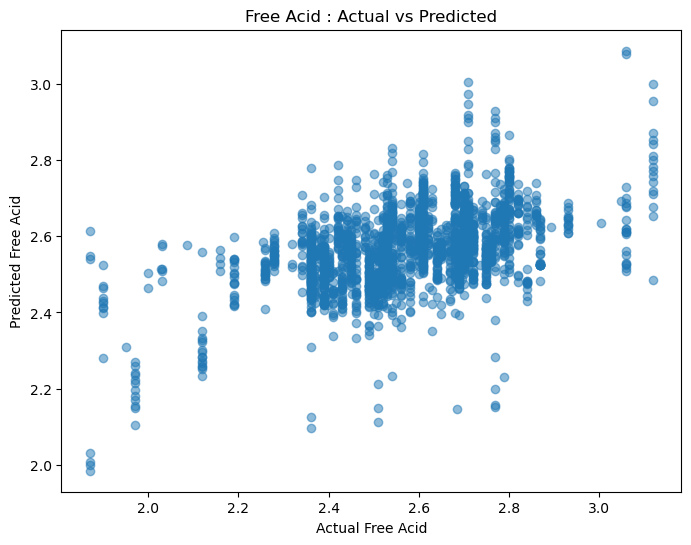

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Free Acid")
plt.ylabel("Predicted Free Acid")
plt.title("Free Acid : Actual vs Predicted")

plt.show()

In [36]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8680, 43)
(2170, 43)
(8680,)
(2170,)


In [34]:
target = "Free AcidPA2_FREEACID"

X = df[feature_cols]
y = df[target]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = mean_squared_error(y_test, y_pred_dt) ** 0.5

print("Decision Tree Results")
print("R² Score :", round(r2_dt,4))
print("MAE :", round(mae_dt,4))
print("RMSE :", round(rmse_dt,4))

Decision Tree Results
R² Score : 0.8752
MAE : 0.014
RMSE : 0.0671


In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

print("Random Forest Results")
print("R² Score :", round(r2_rf,4))
print("MAE :", round(mae_rf,4))
print("RMSE :", round(rmse_rf,4))

Random Forest Results
R² Score : 0.9677
MAE : 0.0151
RMSE : 0.0342


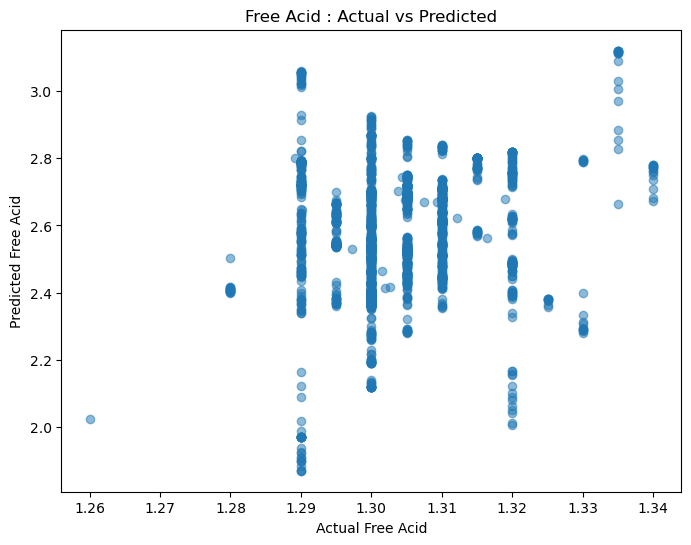

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.xlabel("Actual Free Acid")
plt.ylabel("Predicted Free Acid")

plt.title("Free Acid : Actual vs Predicted")

plt.show()

In [38]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))

                                   Feature  Importance
36                    Cakewash flowFIC2908    0.104942
21           Reactor SolidsREACT-SOLIDS.PV    0.099805
0        Weigh feeder rate AJD2706A-WIC.PV    0.087311
11    H2SO4 TO ATTACK RCT A FLOWFIC2802.PV    0.067211
20             ATTACK RCT D TEMPTI2801D.PV    0.044495
23   LOW LVL FLASH COOLER VACUUMPIC2801.PV    0.040299
5          BAG FLTR SUC PRESSUREPI2705A.PV    0.039427
8      BUCKET ELEVATOR CURRENTJD2710-AI.PV    0.039402
3         BALL MILL VENT SYS TEMPTI2705.PV    0.038943
4   BALL MILL VENT FAN CURRENTGB2705-AI.PV    0.035997
12    H2SO4 TO ATTACK RCT B FLOWFIC2803.PV    0.034991
27         LLFC CIRC PMP SPEEDGA2801-SI.PV    0.033614
31                      HBF SpeedFD2901-SI    0.031469
19             ATTACK RCT B TEMPTI2801B.PV    0.028026
24        TD LLFC I/L & O/L TEMPTDY2806.PV    0.024917
1        Weigh feeder rate BJD2706B-WIC.PV    0.022815
33     CLOTH TRACK BELLOW 1 PRESSUREPI2902    0.022588
28        

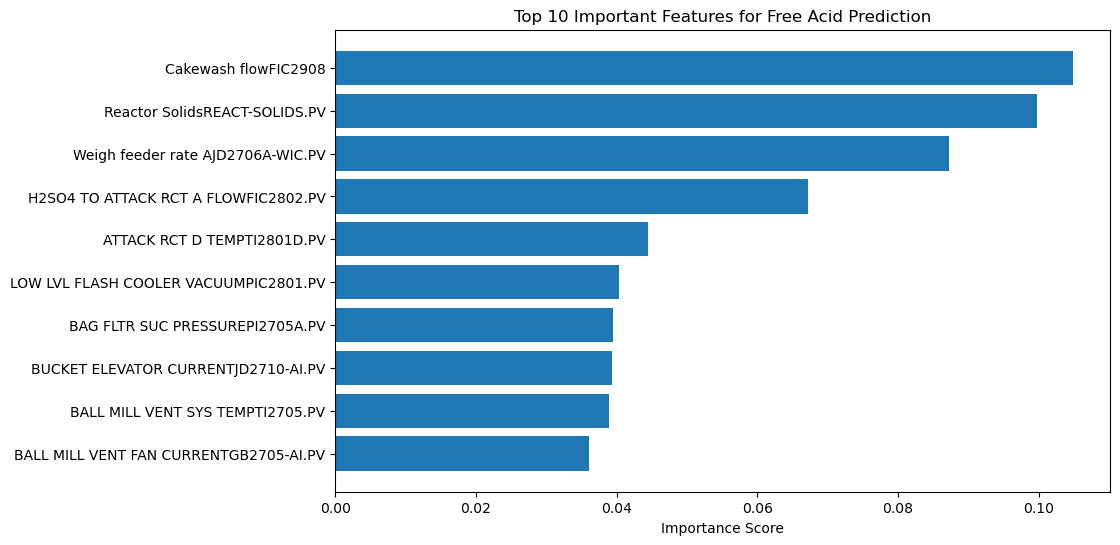

In [39]:
import matplotlib.pyplot as plt

top_10 = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_10["Feature"],
    top_10["Importance"]
)

plt.title(
    "Top 10 Important Features for Free Acid Prediction"
)

plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

In [40]:
target = "Filter SPGPA2_FILSPG"

X = df[feature_cols]
y = df[target]

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = mean_squared_error(y_test, y_pred_dt) ** 0.5

print("Decision Tree Results")
print("R² Score :", round(r2_dt,4))
print("MAE :", round(mae_dt,4))
print("RMSE :", round(rmse_dt,4))

Decision Tree Results
R² Score : 0.9176
MAE : 0.0004
RMSE : 0.0027


In [47]:
target = "Filter SPGPA2_FILSPG"

X = df[feature_cols]
y = df[target]

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [43]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

print("R² Score :", round(r2,4))
print("MAE :", round(mae,4))
print("RMSE :", round(rmse,4))

R² Score : 0.9656
MAE : 0.0005
RMSE : 0.0017


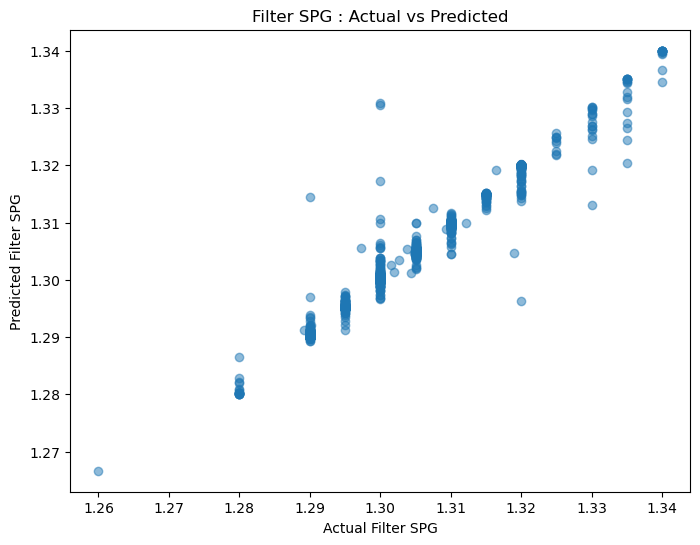

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Filter SPG")
plt.ylabel("Predicted Filter SPG")

plt.title("Filter SPG : Actual vs Predicted")

plt.show()

In [45]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))


                                  Feature  Importance
21          Reactor SolidsREACT-SOLIDS.PV    0.177725
36                   Cakewash flowFIC2908    0.170019
20            ATTACK RCT D TEMPTI2801D.PV    0.096557
31                     HBF SpeedFD2901-SI    0.091949
34    CLOTH TRACK BELLOW 2 PRESSUREPI2903    0.051809
32               HBF support fanGB2902-AI    0.039968
23  LOW LVL FLASH COOLER VACUUMPIC2801.PV    0.035851
35        CLOTH WASH PMP DISCH FLOWFI2909    0.030240
24       TD LLFC I/L & O/L TEMPTDY2806.PV    0.027809
19            ATTACK RCT B TEMPTI2801B.PV    0.022674


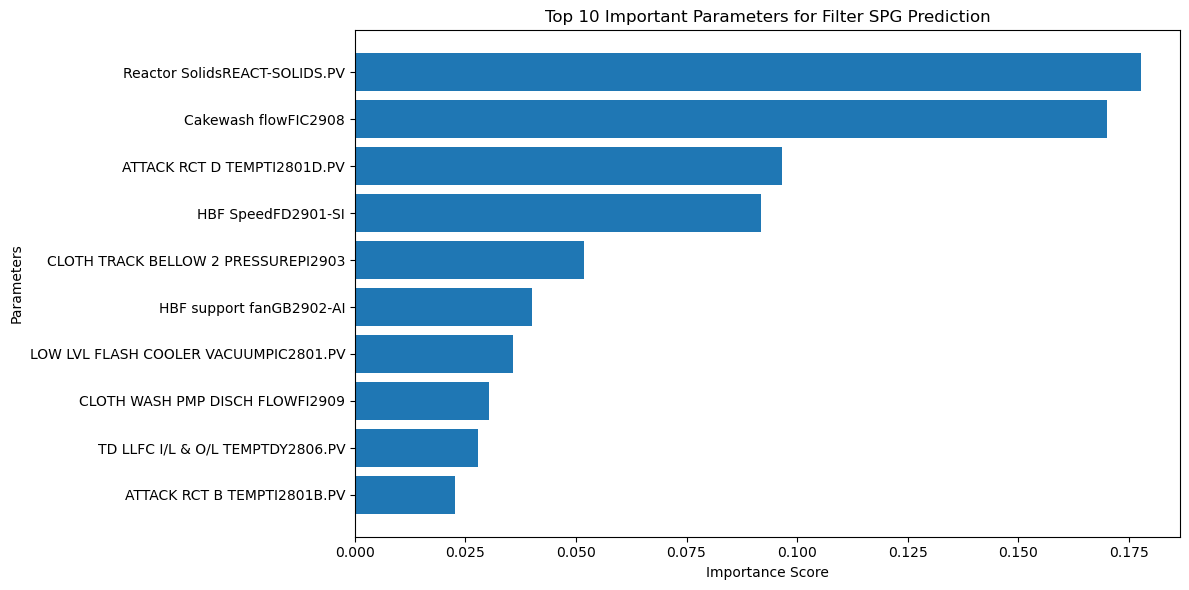

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# Create feature importance dataframe
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Top 10 features
top_10 = importance_df.head(10)

# Plot
plt.figure(figsize=(12,6))

plt.barh(
    top_10["Feature"],
    top_10["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Parameters")
plt.title("Top 10 Important Parameters for Filter SPG Prediction")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [52]:
target = "Slurry SPGPA2_SLURRYSPG"

X = df[feature_cols]
y = df[target]

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [54]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = mean_squared_error(
    y_test,
    y_pred_dt
) ** 0.5

print("Decision Tree Results")
print("R² Score :", round(r2_dt,4))
print("MAE :", round(mae_dt,4))
print("RMSE :", round(rmse_dt,4))

Decision Tree Results
R² Score : 0.9872
MAE : 0.0002
RMSE : 0.0017


In [55]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

print("Random Forest Results")
print("R² Score :", round(r2_rf,4))
print("MAE :", round(mae_rf,4))
print("RMSE :", round(rmse_rf,4))

Random Forest Results
R² Score : 0.9944
MAE : 0.0003
RMSE : 0.0011


In [56]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

                                Feature  Importance
21        Reactor SolidsREACT-SOLIDS.PV    0.767582
28                Scrubber FanGB2801-AI    0.042531
31                   HBF SpeedFD2901-SI    0.026041
36                 Cakewash flowFIC2908    0.020451
32             HBF support fanGB2902-AI    0.018091
19          ATTACK RCT B TEMPTI2801B.PV    0.017598
33  CLOTH TRACK BELLOW 1 PRESSUREPI2902    0.017131
40             Product acid flowFIC2904    0.010898
24     TD LLFC I/L & O/L TEMPTDY2806.PV    0.008743
1     Weigh feeder rate BJD2706B-WIC.PV    0.007041


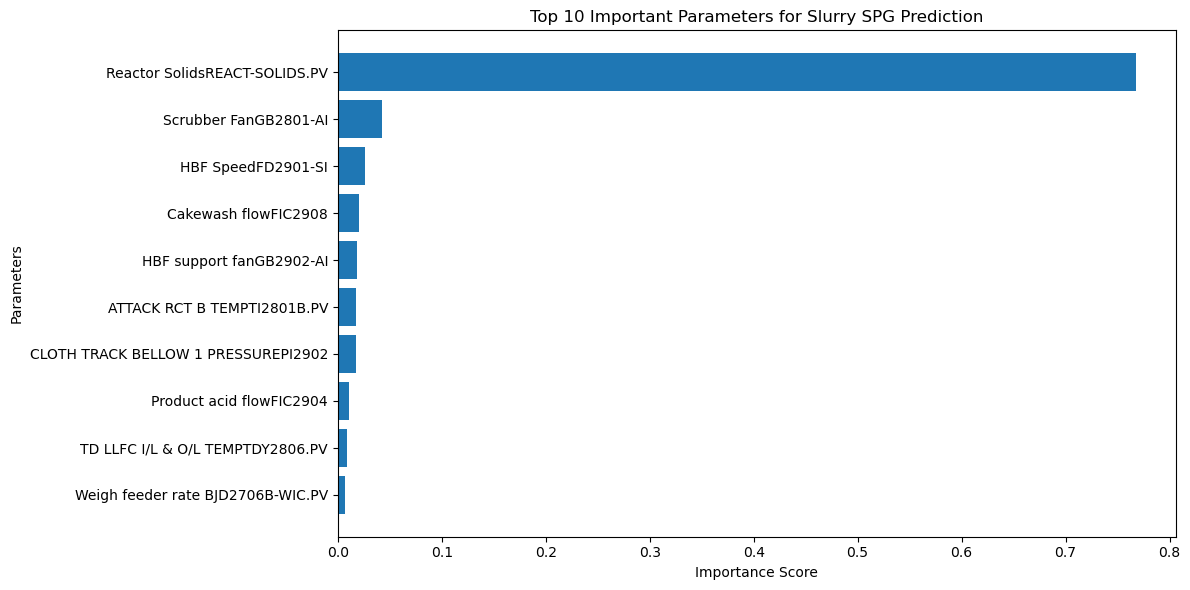

In [57]:
import matplotlib.pyplot as plt

top_10 = importance_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_10["Feature"],
    top_10["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Parameters")

plt.title(
    "Top 10 Important Parameters for Slurry SPG Prediction"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

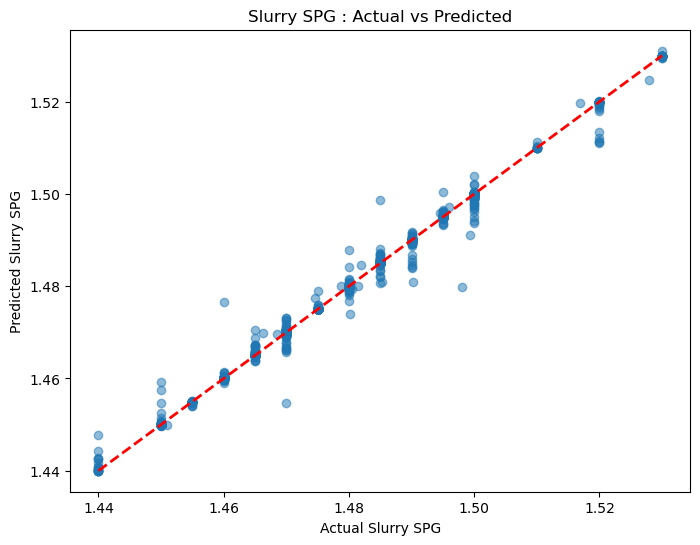

In [58]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Slurry SPG")
plt.ylabel("Predicted Slurry SPG")

plt.title(
    "Slurry SPG : Actual vs Predicted"
)

plt.show()

In [59]:
target = "No 1 filtrate %P2O5"

In [60]:
target = "No 1 filtrate %P2O5"

X = df[feature_cols]
y = df[target]

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [62]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = mean_squared_error(y_test, y_pred_dt) ** 0.5

print("Decision Tree Results")
print("R² Score :", round(r2_dt,4))
print("MAE :", round(mae_dt,4))
print("RMSE :", round(rmse_dt,4))

Decision Tree Results
R² Score : 0.965
MAE : 0.0168
RMSE : 0.1322


In [63]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5

print("Random Forest Results")
print("R² Score :", round(r2_rf,4))
print("MAE :", round(mae_rf,4))
print("RMSE :", round(rmse_rf,4))

Random Forest Results
R² Score : 0.9838
MAE : 0.0289
RMSE : 0.0898


In [64]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "R2 Score": [r2_dt, r2_rf],
    "MAE": [mae_dt, mae_rf],
    "RMSE": [rmse_dt, rmse_rf]
})

print(comparison)

           Model  R2 Score       MAE      RMSE
0  Decision Tree  0.964977  0.016839  0.132170
1  Random Forest  0.983835  0.028945  0.089793


In [65]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

                                Feature  Importance
27      LLFC CIRC PMP SPEEDGA2801-SI.PV    0.208769
32             HBF support fanGB2902-AI    0.130915
33  CLOTH TRACK BELLOW 1 PRESSUREPI2902    0.097694
21        Reactor SolidsREACT-SOLIDS.PV    0.091966
1     Weigh feeder rate BJD2706B-WIC.PV    0.083904
38              Strong wash flowFIC2906    0.043394
31                   HBF SpeedFD2901-SI    0.034642
5       BAG FLTR SUC PRESSUREPI2705A.PV    0.034145
3      BALL MILL VENT SYS TEMPTI2705.PV    0.026697
0     Weigh feeder rate AJD2706A-WIC.PV    0.020012


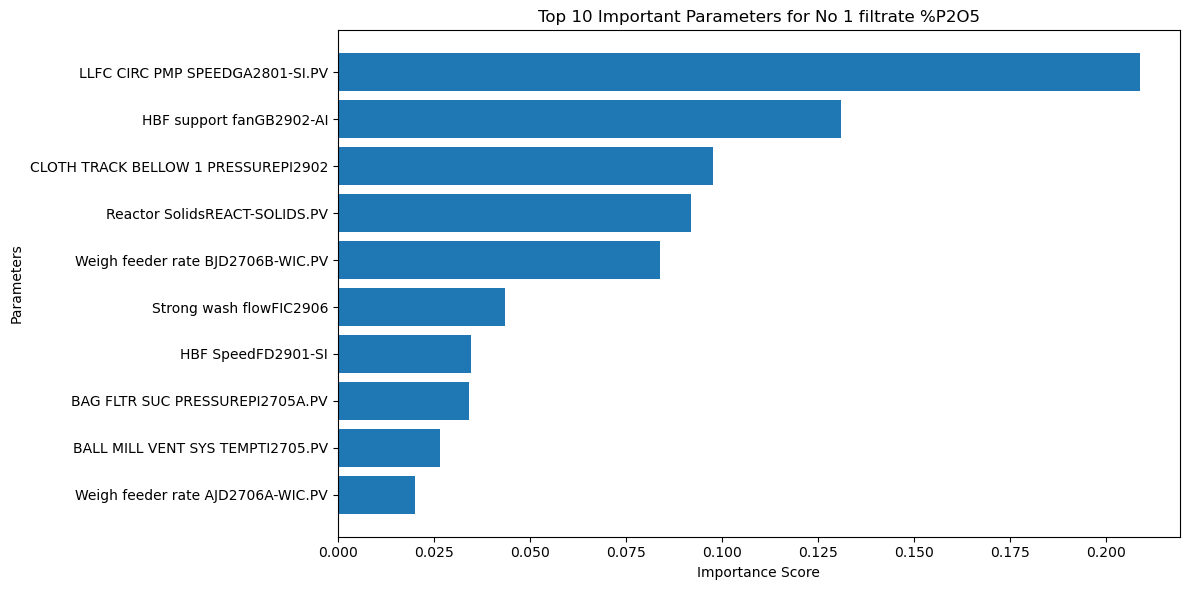

In [66]:
import matplotlib.pyplot as plt

top_10 = importance_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_10["Feature"],
    top_10["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Parameters")
plt.title("Top 10 Important Parameters for No 1 filtrate %P2O5")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [67]:
target = "No 1 filtrate Sp Gr"

X = df[feature_cols]
y = df[target]

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [69]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = mean_squared_error(y_test, y_pred_dt) ** 0.5

print("Decision Tree Results")
print("R² Score :", round(r2_dt,4))
print("MAE :", round(mae_dt,4))
print("RMSE :", round(rmse_dt,4))

Decision Tree Results
R² Score : 0.9319
MAE : 0.0006
RMSE : 0.0036


In [70]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5

print("Random Forest Results")
print("R² Score :", round(r2_rf,4))
print("MAE :", round(mae_rf,4))
print("RMSE :", round(rmse_rf,4))

Random Forest Results
R² Score : 0.9805
MAE : 0.0006
RMSE : 0.0019


In [71]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "R2 Score": [r2_dt, r2_rf],
    "MAE": [mae_dt, mae_rf],
    "RMSE": [rmse_dt, rmse_rf]
})

print(comparison)

           Model  R2 Score       MAE      RMSE
0  Decision Tree  0.931864  0.000569  0.003580
1  Random Forest  0.980465  0.000605  0.001917


In [72]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

                                   Feature  Importance
32                HBF support fanGB2902-AI    0.141226
33     CLOTH TRACK BELLOW 1 PRESSUREPI2902    0.122132
13  RECYCL ACD ATTACK RCT A FLOWFIC2804.PV    0.109723
31                      HBF SpeedFD2901-SI    0.097355
1        Weigh feeder rate BJD2706B-WIC.PV    0.074962
27         LLFC CIRC PMP SPEEDGA2801-SI.PV    0.072825
5          BAG FLTR SUC PRESSUREPI2705A.PV    0.033848
28                   Scrubber FanGB2801-AI    0.029971
21           Reactor SolidsREACT-SOLIDS.PV    0.027703
7         SCREW CONV - CURRENTJD2709-AI.PV    0.026915


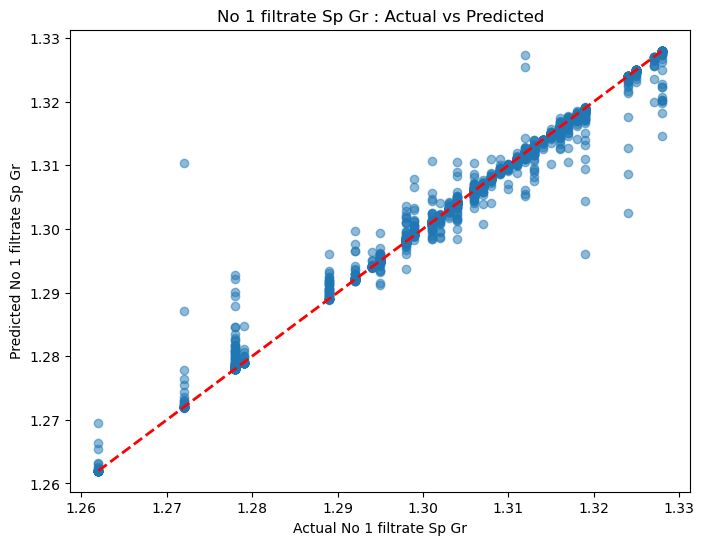

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual No 1 filtrate Sp Gr")
plt.ylabel("Predicted No 1 filtrate Sp Gr")

plt.title("No 1 filtrate Sp Gr : Actual vs Predicted")

plt.show()

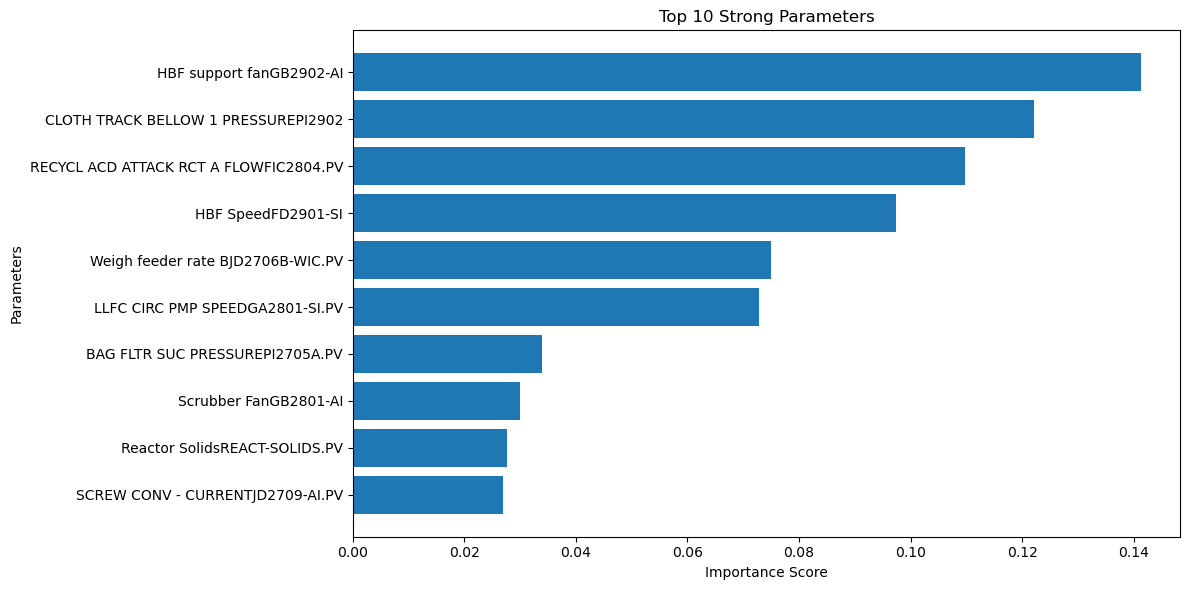

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort descending
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Top 10 Strong Parameters
top_10 = importance_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_10["Feature"],
    top_10["Importance"]
)

plt.title("Top 10 Strong Parameters")
plt.xlabel("Importance Score")
plt.ylabel("Parameters")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [75]:
target = "No 1 filtrate FREEACID"

X = df[feature_cols]
y = df[target]

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [77]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = mean_squared_error(
    y_test,
    y_pred_dt
) ** 0.5

print("Decision Tree Results")
print("R² Score :", round(r2_dt,4))
print("MAE :", round(mae_dt,4))
print("RMSE :", round(rmse_dt,4))

Decision Tree Results
R² Score : 0.96
MAE : 0.0056
RMSE : 0.0384


In [78]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

print("Random Forest Results")
print("R² Score :", round(r2_rf,4))
print("MAE :", round(mae_rf,4))
print("RMSE :", round(rmse_rf,4))

Random Forest Results
R² Score : 0.982
MAE : 0.0078
RMSE : 0.0257


In [79]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "R2 Score": [r2_dt, r2_rf],
    "MAE": [mae_dt, mae_rf],
    "RMSE": [rmse_dt, rmse_rf]
})

print(comparison)

           Model  R2 Score       MAE      RMSE
0  Decision Tree  0.959981  0.005618  0.038365
1  Random Forest  0.982036  0.007838  0.025704


In [80]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

                                   Feature  Importance
13  RECYCL ACD ATTACK RCT A FLOWFIC2804.PV    0.199120
23   LOW LVL FLASH COOLER VACUUMPIC2801.PV    0.124488
21           Reactor SolidsREACT-SOLIDS.PV    0.110780
27         LLFC CIRC PMP SPEEDGA2801-SI.PV    0.059999
22       NEW DIGESTION TANK LEVELLI2802.PV    0.050964
20             ATTACK RCT D TEMPTI2801D.PV    0.037049
4   BALL MILL VENT FAN CURRENTGB2705-AI.PV    0.035938
8      BUCKET ELEVATOR CURRENTJD2710-AI.PV    0.032929
7         SCREW CONV - CURRENTJD2709-AI.PV    0.029726
28                   Scrubber FanGB2801-AI    0.029117


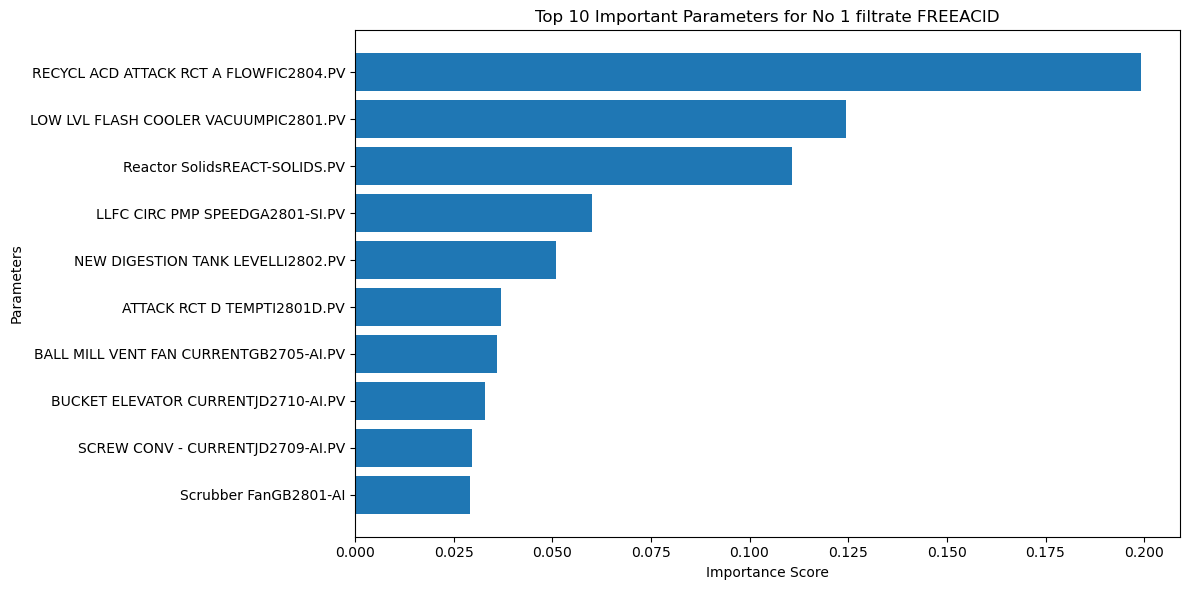

In [81]:
import matplotlib.pyplot as plt

top_10 = importance_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_10["Feature"],
    top_10["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Parameters")

plt.title(
    "Top 10 Important Parameters for No 1 filtrate FREEACID"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [82]:
target = "Gypsum TP2O5 loss"

X = df[feature_cols]
y = df[target]

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [84]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = mean_squared_error(
    y_test,
    y_pred_dt
) ** 0.5

print("Decision Tree Results")
print("R² Score :", round(r2_dt,4))
print("MAE :", round(mae_dt,4))
print("RMSE :", round(rmse_dt,4))

Decision Tree Results
R² Score : 0.9623
MAE : 0.0053
RMSE : 0.0404


In [85]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

print("Random Forest Results")
print("R² Score :", round(r2_rf,4))
print("MAE :", round(mae_rf,4))
print("RMSE :", round(rmse_rf,4))

Random Forest Results
R² Score : 0.9788
MAE : 0.0102
RMSE : 0.0303


In [86]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

                                Feature  Importance
28                Scrubber FanGB2801-AI    0.219661
21        Reactor SolidsREACT-SOLIDS.PV    0.080642
32             HBF support fanGB2902-AI    0.063769
3      BALL MILL VENT SYS TEMPTI2705.PV    0.049010
36                 Cakewash flowFIC2908    0.047599
33  CLOTH TRACK BELLOW 1 PRESSUREPI2902    0.046680
22    NEW DIGESTION TANK LEVELLI2802.PV    0.043619
31                   HBF SpeedFD2901-SI    0.039493
19          ATTACK RCT B TEMPTI2801B.PV    0.036768
20          ATTACK RCT D TEMPTI2801D.PV    0.033049


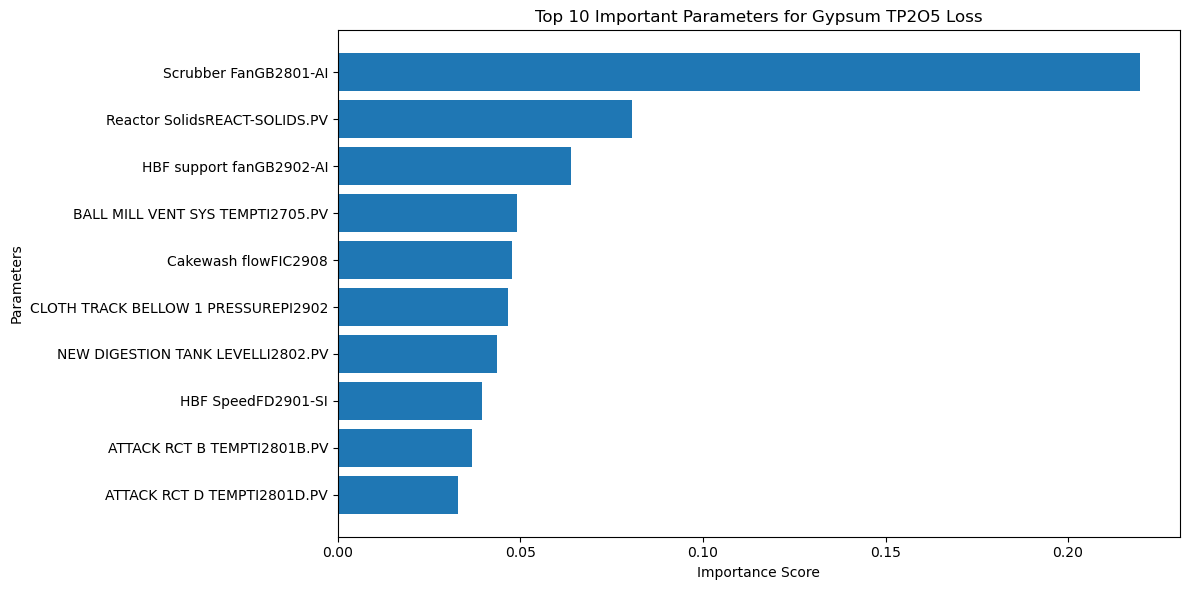

In [87]:
import matplotlib.pyplot as plt

top_10 = importance_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_10["Feature"],
    top_10["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Parameters")

plt.title(
    "Top 10 Important Parameters for Gypsum TP2O5 Loss"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [6]:
import pandas as pd

final_results = pd.DataFrame({

    "Target": [
        "Free Acid",
        "Filter SPG",
        "Slurry SPG",
        "No 1 filtrate %P2O5",
        "No 1 filtrate Sp Gr",
        "No 1 filtrate FREEACID",
        "Gypsum TP2O5 loss"
    ],

    "R2 Score": [
        0.9677,
        0.9656,
        0.9944,
        0.9838,
        0.9805,
        0.9820,
        0.9788
    ],

    "MAE": [
        0.0151,
        0.0005,
        0.0003,
        0.0289,
        0.0006,
        0.0078,
        0.0102
    ],

    "RMSE": [
        0.0342,
        0.0017,
        0.0011,
        0.0898,
        0.0019,
        0.0257,
        0.0303
    ]

})

print(final_results)

                   Target  R2 Score     MAE    RMSE
0               Free Acid    0.9677  0.0151  0.0342
1              Filter SPG    0.9656  0.0005  0.0017
2              Slurry SPG    0.9944  0.0003  0.0011
3     No 1 filtrate %P2O5    0.9838  0.0289  0.0898
4     No 1 filtrate Sp Gr    0.9805  0.0006  0.0019
5  No 1 filtrate FREEACID    0.9820  0.0078  0.0257
6       Gypsum TP2O5 loss    0.9788  0.0102  0.0303


In [10]:
from sklearn.model_selection import train_test_split

target = "Free AcidPA2_FREEACID"

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

NameError: name 'feature_cols' is not defined

In [11]:
print(df.shape)

(10850, 51)


In [12]:
target_cols = [
    'Filter SPGPA2_FILSPG',
    'Slurry SPGPA2_SLURRYSPG',
    'Free AcidPA2_FREEACID',
    'No 1 filtrate %P2O5',
    'No 1 filtrate Sp Gr',
    'No 1 filtrate FREEACID',
    'Gypsum TP2O5 loss'
]

feature_cols = [
    col for col in df.columns
    if col not in target_cols
]

print("Feature Columns :", len(feature_cols))

Feature Columns : 44


In [13]:
from sklearn.model_selection import train_test_split

target = "Free AcidPA2_FREEACID"

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8680, 44)
(2170, 44)


In [15]:
print(df.dtypes.value_counts())

float64           46
object             4
datetime64[ns]     1
Name: count, dtype: int64


print(df.dtypes.value_counts())

In [16]:
object_cols = df.select_dtypes(include=['object']).columns

print(object_cols.tolist())

['RECYCL ACD ATTACK RCT B FLOWFIC2805.PV', 'HBF support fanGB2902-AI', 'Weak wash flowFIC2907', 'Cake wash temperatureTI2908']


In [17]:
date_cols = df.select_dtypes(include=['datetime64']).columns

print(date_cols.tolist())

['Date']


In [19]:
df.select_dtypes(include=['datetime64[ns]']).columns

Index(['Date'], dtype='object')

In [20]:
df_ml = df.drop(columns=['Date'])

In [21]:
print(df_ml.dtypes.value_counts())

float64    46
object      4
Name: count, dtype: int64


In [22]:
df_ml.select_dtypes(include=['object']).columns.tolist()

['RECYCL ACD ATTACK RCT B FLOWFIC2805.PV',
 'HBF support fanGB2902-AI',
 'Weak wash flowFIC2907',
 'Cake wash temperatureTI2908']

In [23]:
print(df_ml.dtypes.value_counts())

float64    46
object      4
Name: count, dtype: int64
